# Directed Graphical Models

# 1. Introduction

* Purpose of the Tutorial: Briefly explain the objectives of the tutorial, emphasizing the practical skills students will gain by learning about graphical representations and Bayesian networks.

* Expected Outcomes: Outline what students can expect to learn, such as understanding Bayesian networks, using ``pgmpy`` for creating and querying Bayesian models, and applying these models to real-world data.


# 2 Bayesian Networks

Ensure pgmpy (version 1.0 or later; this notebook was tested with 1.1.2), [graphviz](https://pygraphviz.github.io/documentation/stable/install.html) with the `pygraphviz` Python package, and pomegranate (version 1.0 or later, needed in Section 3) are installed in the Python environment. If not installed, they can be added via pip, conda install or brew install. Note that pgmpy 1.0 renamed the `BayesianModel` / `BayesianNetwork` class to `DiscreteBayesianNetwork`; this notebook uses the new name throughout.

## Installation and import

Then, import the required module for creating and visualizing basic graphs:

In [31]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx 
from IPython.display import display, Image

### Exercise 2.1: Designing a Basic Graph

#### Scenario

You are analyzing the factors that influence the performance of an outdoor event. Several elements play a role in shaping the outcome of the event. First, the overall atmospheric condition at the event venue affects various aspects of the event, ranging from clear skies to rain or cloudy weather, which in turn impacts other conditions. Additionally, there is a system installed at the venue that responds to environmental changes by automatically turning on or off based on certain conditions, which can affect the environment further. The condition of the venue itself, particularly whether it remains comfortable and accessible, is influenced by both the atmospheric conditions and the operation of the system. Furthermore, the number of people who choose to attend the event is directly related to the atmospheric condition, as more favorable conditions generally attract larger crowds. Finally, the overall success of the event depends on both how many people attended and whether the venue remains in a suitable condition to host the event comfortably.


#### Task
* Identify the key random variables based on the scenario described and give each variable an appropriate name.
* Design a Bayesian network that represents the relationships between the variables: weather, sprinkler, grass wet, event success and attendees.
* Build a graph structure using ``pgmpy``, without assigning and probabilities or states to the nodes. Focus on capturing the dependencies between the variables.


Random variables:

- Weather: it can be sunny, rainy, or cloudy.
- Sprinkler: whether the garden's sprinkler system is on or off.
- Grass wet: whether the grass is wet or dry.
- Event success: wherher the outdoor event is a success or not.
- Attendees: the number of pepole attending the event.

Relationships between the variables are as follows:

* The weather affects whether the sprinkler is turned on or not.
* Both the weather and the sprinkler system affect whether the grass is wet.
* Wet grass affects the success of the event.
* The weather also directly influences the number of attendees.
* The success of the event depends on both the number of attendees and whether the grass is wet.

Let’s start by creating a simple directed graph. A directed graph, or digraph, consists of nodes connected by directed edges (arrows).

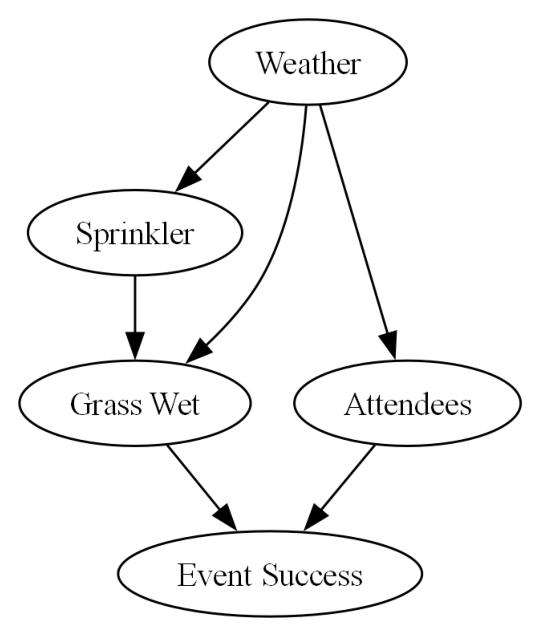

In [32]:
from pgmpy.models import DiscreteBayesianNetwork
import matplotlib.pyplot as plt
from PIL import Image
import io

# Create a new Bayesian network
model = DiscreteBayesianNetwork()

# Add nodes (variables)
model.add_nodes_from(['Weather', 'Sprinkler', 'Grass Wet', 'Event Success', 'Attendees'])

# Add edges (relationships)
model.add_edges_from([('Weather', 'Sprinkler'),
                      ('Weather', 'Grass Wet'),
                      ('Sprinkler', 'Grass Wet'),
                      ('Weather', 'Attendees'),
                      ('Grass Wet', 'Event Success'),
                      ('Attendees', 'Event Success')])

# Convert model into pygraphviz object and visualize
model_graphviz = model.to_graphviz()
model_graphviz.graph_attr.update(size="15,8!")
# Draw the graph to binary PNG data
png_data = model_graphviz.draw(format='png', prog='dot')

# Create an image from the binary data
img = Image.open(io.BytesIO(png_data))

# Display the image
plt.figure(figsize=(15, 8))
plt.imshow(img, aspect='equal')
plt.axis('off')  # Hide axes
plt.show()

### Exercise 2.2: Adding Conditional Probability Distributions (CPDs) to the Graph (by given probabilities)

#### Scenario and Probabilities

The scenario is the same as in Exercise 1. Now, you need to add conditional probability distributions (CPDs) to the graph. The probabilities are as follows:

* Weather:
    * Sunny: $70\%$ probability
    * Rainy: $20\%$ probability
    * Cloudy: $10\%$ probability

The weather influences both the operation of the sprinkler system and the attendence at the event.

* Sprinkler (dependens on weather):
    * On:
        * Sunny: $70\%$
        * Rainy: $10\%$
        * Cloudy: $30\%$
    * Off:
        * Sunny: $30\%$
        * Rainy: $90\%$
        * Cloudy: $70\%$

* Grass wet (depends on weather and sprinkler):
    * Wet:
        * Sunny and sprinkle On: $99\%$
        * Sunny and sprinkle Off: $10\%$
        * Rainy and sprinkle On: $90\%$
        * Rainy and sprinkle Off: $70\%$
        * Cloudy and sprinkle On: $80\%$
        * Cloudy and sprinkle Off: $30\%$
    * Dry:
        * Sunny and sprinkle On: $1\%$
        * Sunny and sprinkle Off: $90\%$
        * Rainy and sprinkle On: $10\%$
        * Rainy and sprinkle Off: $30\%$
        * Cloudy and sprinkle On: $20\%$
        * Cloudy and sprinkle Off: $70\%$

* Attendeees (depends on weather):
    * High attendance:
        * Sunny: $60\%$
        * Rainy: $30\%$
        * Cloudy: $50\%$
    * Medium attendance (inversely to high attendance):
        * Sunny: $30\%$
        * Rainy: $50\%$
        * Cloudy: $40\%$
    * Low attendance:
        * Sunny: $10\%$
        * Rainy: $20\%$
        * Cloudy: $10\%$

* Event success (depends on grass wet and attendees):
    * Success:
        * Dry grass and high attendance: $90\%$
        * Wet grass and high attendance: $80\%$
        * Dry grass and medium attendance: $70\%$
        * Wet grass and medium attendance: $60\%$
        * Dry grass and low attendance: $40\%$
        * Wet grass and low attendance: $20\%$
    * Failure is simply the complement of success.




In [33]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Weather: Sunny, Rainy, Cloudy
cpd_weather = TabularCPD(variable='Weather', variable_card=3, 
                         values=[[0.7], [0.2], [0.1]],  # Probabilities for Sunny, Rainy, Cloudy
                         state_names={'Weather': ['Sunny', 'Rainy', 'Cloudy']})

# Sprinkler: Depends on Weather
cpd_sprinkler = TabularCPD(variable='Sprinkler', variable_card=2,
                           values=[[0.7, 0.1, 0.3],  # Sprinkler On
                                   [0.3, 0.9, 0.7]],  # Sprinkler Off
                           evidence=['Weather'], evidence_card=[3],
                           state_names={'Sprinkler': ['On', 'Off'], 'Weather': ['Sunny', 'Rainy', 'Cloudy']})

# Grass Wet: Depends on Weather and Sprinkler
cpd_grass_wet = TabularCPD(variable='Grass Wet', variable_card=2,
                           values=[[0.99, 0.10, 0.90, 0.70, 0.80, 0.30],  # Grass Wet
                                   [0.01, 0.90, 0.10, 0.30, 0.20, 0.70]],  # Grass Dry
                           evidence=['Sprinkler', 'Weather'], evidence_card=[2, 3],
                           state_names={'Grass Wet': ['Wet', 'Dry'], 'Sprinkler': ['On', 'Off'], 'Weather': ['Sunny', 'Rainy', 'Cloudy']})

# Attendees: Depends on Weather
cpd_attendees = TabularCPD(variable='Attendees', variable_card=3,
                           values=[[0.6, 0.3, 0.5],  # High Attendance
                                   [0.3, 0.5, 0.4],  # Medium Attendance
                                   [0.1, 0.2, 0.1]],  # Low Attendance
                           evidence=['Weather'], evidence_card=[3],
                           state_names={'Attendees': ['High', 'Medium', 'Low'], 'Weather': ['Sunny', 'Rainy', 'Cloudy']})

# Event Success: Depends on Grass Wet and Attendees
cpd_event_success = TabularCPD(variable='Event Success', variable_card=2,
                               values=[[0.90, 0.80, 0.70, 0.60, 0.40, 0.20],  # Success
                                       [0.10, 0.20, 0.30, 0.40, 0.60, 0.80]],  # Failure
                               evidence=['Grass Wet', 'Attendees'], evidence_card=[2, 3],
                               state_names={'Event Success': ['Success', 'Failure'], 
                                            'Grass Wet': ['Wet', 'Dry'],
                                            'Attendees': ['High', 'Medium', 'Low']})

# Step 3: Add the CPDs to the Bayesian Network
model.add_cpds(cpd_weather, cpd_sprinkler, cpd_grass_wet, cpd_attendees, cpd_event_success)

In [34]:
# Validate the model
assert model.check_model(), "The model has inconsistencies."

### Exercise 2.3: Adding Conditional Probability Distributions (CPDs) to the Graph (by given dataset)

In this exercise, you will add conditional probability distributions (CPDs) to the graph based on a dataset. In this case, you will not be given the probabilities, but you will use a dataset to calculate them.

* Task:
    * Use the dataset provided below and use package ``pgmpy`` with Maximum Likelihood Estimation (MLE) to calculate the probabilities for the CPDs.
    * What are the probabilities for the CPDs?

In [5]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork


In [35]:
data = pd.DataFrame({
    'Weather': ['Sunny', 'Rainy', 'Cloudy', 'Sunny', 'Rainy', 
                'Cloudy', 'Sunny', 'Rainy', 'Sunny', 'Cloudy'],
    'Sprinkler': ['On', 'Off', 'Off', 'On', 'On', 
                  'Off', 'On', 'Off', 'On', 'Off'],
    'Grass Wet': ['Wet', 'Wet', 'Dry', 'Wet', 'Wet', 
                  'Dry', 'Wet', 'Wet', 'Wet', 'Dry'],
    'Attendees': ['High', 'Low', 'Medium', 'High', 'Low', 
                  'Medium', 'High', 'Low', 'High', 'Medium'],
    'Event Success': ['Success', 'Failure', 'Success', 'Success', 'Failure', 
                      'Success', 'Success', 'Failure', 'Success', 'Success']
})

In [36]:
model = DiscreteBayesianNetwork([('Weather', 'Sprinkler'),
                         ('Weather', 'Grass Wet'),
                         ('Sprinkler', 'Grass Wet'),
                         ('Weather', 'Attendees'),
                         ('Grass Wet', 'Event Success'),
                         ('Attendees', 'Event Success')])

# Step 3: Learn CPDs using Maximum Likelihood Estimation (MLE)
model.fit(data)   # maximum likelihood estimation (MLE) is the default estimator of fit()

In [37]:
for cpd in model.get_cpds():
    print(cpd)

+-----------------+-----+
| Weather(Cloudy) | 0.3 |
+-----------------+-----+
| Weather(Rainy)  | 0.3 |
+-----------------+-----+
| Weather(Sunny)  | 0.4 |
+-----------------+-----+
+----------------+-----------------+--------------------+----------------+
| Weather        | Weather(Cloudy) | Weather(Rainy)     | Weather(Sunny) |
+----------------+-----------------+--------------------+----------------+
| Sprinkler(Off) | 1.0             | 0.6666666666666666 | 0.0            |
+----------------+-----------------+--------------------+----------------+
| Sprinkler(On)  | 0.0             | 0.3333333333333333 | 1.0            |
+----------------+-----------------+--------------------+----------------+
+----------------+-----------------+----------------+-----+-----------------+----------------+----------------+
| Sprinkler      | Sprinkler(Off)  | Sprinkler(Off) | ... | Sprinkler(On)   | Sprinkler(On)  | Sprinkler(On)  |
+----------------+-----------------+----------------+-----+----------

In [38]:
for cpd in model.get_cpds():
    print(f"CPD for {cpd.variable}:")
    print(cpd.get_values())

CPD for Weather:
[[0.3]
 [0.3]
 [0.4]]
CPD for Sprinkler:
[[1.         0.66666667 0.        ]
 [0.         0.33333333 1.        ]]
CPD for Grass Wet:
[[1.  0.  0.5 0.5 0.  0. ]
 [0.  1.  0.5 0.5 1.  1. ]]
CPD for Attendees:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
CPD for Event Success:
[[0.5 0.  0.5 1.  0.  0.5]
 [0.5 1.  0.5 0.  1.  0.5]]


In [39]:
import pandas as pd

# Helper function to display the CPD table in a formatted way
def print_cpd_as_table(cpd):
    # Get the list of variables (evidence) and the main variable
    variables = cpd.variables
    evidence = cpd.variables[1:]  # Exclude the main variable (the first one)

    # If there is no evidence, handle it as a simple prior
    if len(evidence) == 0:
        # Create a simple DataFrame for the prior
        table = pd.DataFrame(cpd.get_values().T, columns=[f'{cpd.variable}({state})' for state in cpd.state_names[cpd.variable]])
        print(f"\nCPD for {cpd.variable} (Prior):")
        print(table)
    else:
        # Create the header row, with the states of the main variable
        headers = [' | '.join(evidence)] + [f'{var}({state})' for var, state in zip([cpd.variable]*cpd.get_values().shape[0], cpd.state_names[cpd.variable])]
        
        # Prepare the data rows (evidence and probabilities)
        index = pd.MultiIndex.from_product([cpd.state_names[var] for var in evidence], names=evidence)
        table = pd.DataFrame(cpd.get_values().T, columns=headers[1:], index=index)

        # Print the table
        print(f"\nCPD for {cpd.variable}:")
        print(table)

# Print each CPD using the formatted table
for cpd in model.get_cpds():
    print_cpd_as_table(cpd)


CPD for Weather (Prior):
   Weather(Cloudy)  Weather(Rainy)  Weather(Sunny)
0              0.3             0.3             0.4

CPD for Sprinkler:
         Sprinkler(Off)  Sprinkler(On)
Weather                               
Cloudy         1.000000       0.000000
Rainy          0.666667       0.333333
Sunny          0.000000       1.000000

CPD for Grass Wet:
                   Grass Wet(Dry)  Grass Wet(Wet)
Sprinkler Weather                                
Off       Cloudy              1.0             0.0
          Rainy               0.0             1.0
          Sunny               0.5             0.5
On        Cloudy              0.5             0.5
          Rainy               0.0             1.0
          Sunny               0.0             1.0

CPD for Attendees:
         Attendees(High)  Attendees(Low)  Attendees(Medium)
Weather                                                    
Cloudy               0.0             0.0                1.0
Rainy                0.0             

In [40]:
# Validate the model to ensure consistency
assert model.check_model(), "The model has inconsistencies."

### 2.4 D-Separation

Consider again the event model of Exercises 2.1 to 2.3:

* Weather $\rightarrow$ Sprinkler, Weather $\rightarrow$ Grass Wet, Sprinkler $\rightarrow$ Grass Wet
* Weather $\rightarrow$ Attendees
* Grass Wet $\rightarrow$ Event Success, Attendees $\rightarrow$ Event Success

For each question below, first answer it **by hand**: list every path between the two variables, classify each intermediate node on the path as a chain, a fork or a collider, and state whether the path is blocked or active given the observed set. Then **verify your answer with code**. No code is provided this time: build the network structure in ``pgmpy`` and find the method that tests d-connection or d-separation (recall from the Week 8 seminar that ``pgmpy`` reports d-*connection*, the opposite of d-separation). Your explanation and your code must agree; if they do not, one of them is wrong.

In [41]:
from pgmpy.models import DiscreteBayesianNetwork
from itertools import combinations

event_model = DiscreteBayesianNetwork([('Weather', 'Sprinkler'),
                                       ('Weather', 'Grass Wet'),
                                       ('Sprinkler', 'Grass Wet'),
                                       ('Weather', 'Attendees'),
                                       ('Grass Wet', 'Event Success'),
                                       ('Attendees', 'Event Success')])

def d_separated(a, b, observed=()):
    """pgmpy tests d-connection; d-separation is its negation."""
    return not event_model.is_dconnected(a, b, observed=list(observed))

#### Question 1: Are Sprinkler and Attendees d-separated given Weather?

**Answer 1: Yes, d-separated.** There are three paths from Sprinkler to Attendees.

* Sprinkler $\leftarrow$ **Weather** $\rightarrow$ Attendees. Weather is a fork; it is observed, so the path is **blocked**.
* Sprinkler $\rightarrow$ **Grass Wet** $\leftarrow$ Weather $\rightarrow$ Attendees. Grass Wet is a collider; neither it nor a descendant (Event Success) is observed, so the path is **blocked** (Weather, a fork further along, is blocked as well).
* Sprinkler $\rightarrow$ Grass Wet $\rightarrow$ **Event Success** $\leftarrow$ Attendees. Event Success is a collider and is not observed, so the path is **blocked**.

All paths are blocked, so Sprinkler $\perp$ Attendees $\mid$ Weather.

In [42]:
print(d_separated('Sprinkler', 'Attendees', ['Weather']))

True


#### Question 2: Are Sprinkler and Attendees d-separated given {Weather, Event Success}?

Compare with Question 1: which node changed its role, and why?

**Answer 2: No, d-connected.** The observed set now contains Event Success, which is the collider on the third path of Question 1. Observing a collider **activates** it: Sprinkler $\rightarrow$ Grass Wet $\rightarrow$ Event Success $\leftarrow$ Attendees becomes active because Grass Wet is an unobserved chain node and Event Success is an observed collider. The other two paths remain blocked by Weather, but one active path is enough. This is explaining away: once we know the event succeeded, learning that the sprinkler was on (so the grass was probably wet) makes high attendance a more likely explanation.

In [43]:
print(d_separated('Sprinkler', 'Attendees', ['Weather', 'Event Success']))

False


#### Question 3: Are Sprinkler and Attendees d-separated given {Weather, Grass Wet}?

Grass Wet is a collider on one of the paths. Explain why observing it does, or does not, connect Sprinkler and Attendees here.

**Answer 3: Yes, d-separated.** Observing the collider Grass Wet activates it on the path Sprinkler $\rightarrow$ Grass Wet $\leftarrow$ Weather $\rightarrow$ Attendees, but the same path also passes through the fork Weather, which is observed and therefore blocks it. A path is active only if **every** intermediate node lets information through. On the path Sprinkler $\rightarrow$ Grass Wet $\rightarrow$ Event Success $\leftarrow$ Attendees, Grass Wet is a chain node (not a collider), so observing it blocks the path; Event Success is an unobserved collider, which blocks it too. The direct fork path is blocked by Weather. Hence Sprinkler $\perp$ Attendees $\mid$ {Weather, Grass Wet}.

In [44]:
print(d_separated('Sprinkler', 'Attendees', ['Weather', 'Grass Wet']))

True


#### Question 4: Are Sprinkler and Event Success d-separated given Grass Wet?

If they are not, name the smallest set of *additional* variables that makes them d-separated, and check every candidate with code.

**Answer 4: No, d-connected.** The obvious path Sprinkler $\rightarrow$ Grass Wet $\rightarrow$ Event Success is blocked (Grass Wet is an observed chain node). But there is a second, longer path: Sprinkler $\leftarrow$ **Weather** $\rightarrow$ **Attendees** $\rightarrow$ Event Success. Weather is an unobserved fork and Attendees an unobserved chain, so this path is **active**. (The path Sprinkler $\leftarrow$ Weather $\rightarrow$ Grass Wet $\rightarrow$ Event Success is blocked at Grass Wet.)

Adding either **Weather** or **Attendees** to the observed set blocks the remaining active path, so a single additional variable suffices: {Grass Wet, Weather} and {Grass Wet, Attendees} both d-separate Sprinkler and Event Success.

In [45]:
print(d_separated('Sprinkler', 'Event Success', ['Grass Wet']))
for extra in ['Weather', 'Attendees']:
    print(extra, d_separated('Sprinkler', 'Event Success', ['Grass Wet', extra]))

False
Weather True
Attendees True


#### Question 5: Which sets d-separate Weather and Event Success?

Show by hand that neither {Grass Wet} alone nor {Attendees} alone d-separates Weather from Event Success, and find the smallest set that does. Then verify with code by testing **every** subset of {Sprinkler, Grass Wet, Attendees} as the observed set and printing those that d-separate the two variables.

**Answer 5.** The paths from Weather to Event Success are

* Weather $\rightarrow$ Grass Wet $\rightarrow$ Event Success,
* Weather $\rightarrow$ Sprinkler $\rightarrow$ Grass Wet $\rightarrow$ Event Success,
* Weather $\rightarrow$ Attendees $\rightarrow$ Event Success.

All three are chains, so a path is blocked exactly when one of its intermediate nodes is observed. Observing {Grass Wet} blocks the first two paths but leaves the Attendees path active; observing {Attendees} blocks only the third. Sprinkler is never sufficient because the first path bypasses it. The smallest separating set is therefore **{Grass Wet, Attendees}**, and the only other separating set among the subsets of {Sprinkler, Grass Wet, Attendees} is the full set, which contains it.

In [46]:
others = ['Sprinkler', 'Grass Wet', 'Attendees']
for k in range(len(others) + 1):
    for Z in combinations(others, k):
        if d_separated('Weather', 'Event Success', Z):
            print("d-separated by", set(Z))

# pgmpy can also return a minimal separator directly
print(event_model.minimal_dseparator('Weather', 'Event Success'))

d-separated by {'Grass Wet', 'Attendees'}
d-separated by {'Grass Wet', 'Sprinkler', 'Attendees'}
{'Grass Wet', 'Attendees'}


# 3. Debugging a Deep Bayesian Network on Real Data

Part IV of the Week 8 seminar built a *deep Bayesian network* with pomegranate: a neural network (the *encoder*) mapped a raw, continuous observation to a categorical variable, and a Bayesian network reasoned over that variable together with the rest of the domain knowledge. Here the same idea is applied to a real clinical dataset and the network is then used to answer the questions a clinician would ask about one patient: not only "diseased or not", but how the belief changes as test results arrive, how a symptom's evidence depends on other symptoms, and which overall explanation of the patient is most probable. The code was written in a hurry and **contains five bugs**. Find and fix them.

This section uses pomegranate $\geq$ 1.0 (built on PyTorch), as in Week 8: `pip install pomegranate` if needed.

### Data

The [UCI Heart Disease](https://archive.ics.uci.edu/dataset/45/heart-disease) data (Cleveland Clinic, 303 patients) is one of the oldest benchmarks for medical diagnosis. The file `heart.csv` distributed with this notebook is the widely used Kaggle release of the Cleveland subset; the loading cell downloads it if the file is missing. We use

| Variable | Values | Role in the network |
| --- | --- | --- |
| `sex` | 0 = female, 1 = male | root |
| `cp` | chest pain type, 4 categories | symptom, depends on `disease` |
| `exang` | exercise-induced angina, 0/1 | symptom, depends on `disease` and `cp` |
| `thal` | thallium stress-test result, 3 categories | test, depends on `disease` |
| `risk` | **learned** from five continuous measurements (age, resting blood pressure, cholesterol, maximum heart rate, ST depression), 0/1 | test, depends on `disease` |
| `disease` | 0/1, presence of coronary artery disease | target |

The five continuous measurements cannot be parents of a tabular CPD. As with the X-ray image in Week 8, an encoder turns them into a single categorical node `risk` (its prediction of `disease` from the measurements alone), and the Bayesian network learns how reliable this "virtual test" is, $P(\text{risk} \mid \text{disease})$, and combines it with the symptoms and the thallium test.

One data-quality note: in this Kaggle release the column `target` is coded the opposite way to the UCI documentation. The rows with `target = 1` have fewer risk indicators (less exercise-induced angina, lower ST depression, higher maximum heart rate), so `target = 1` is the *healthy* group. The loading cell therefore defines `disease = 1 - target`. Seven rows with undocumented codes (`thal = 0`, `ca = 4`) are dropped.

### Task

Sections 3.2 to 3.4 contain **five bugs**; Section 3.1 is correct. One bug stops the notebook with an error, the other four run silently and produce answers that are wrong or that do not answer the question asked. Work through the cells in order; each query cell states what it is meant to compute, so compare every output with that statement. Record each bug in the table.

When everything is fixed you should see, approximately: an encoder accuracy of 0.65 to 0.70 on the test patients; a prior in Query 1 equal to the prevalence printed in Section 3.1; a posterior for patient A in Query 2 that rises from about 0.54 to above 0.95 as the evidence accumulates, and one for patient B that falls below 0.02; and two clearly different numbers in Query 3.

| # | Cell (section) | Symptom | Cause | Fix |
| --- | --- | --- | --- | --- |
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |

### Solution: the five bugs

Each fix is marked with `# FIX n` in the corrected cells below.

| # | Cell (section) | Symptom | Cause | Fix |
| --- | --- | --- | --- | --- |
| 1 | `tensors` (3.2) | `RuntimeError: expected target dtype to be Long or Byte, but got Float` from `CrossEntropyLoss` | The categorical tensor is created with `dtype=np.float32`; class labels for cross-entropy, and integer states for pomegranate, must be integers | `dtype=np.int64` |
| 2 | `structure` (3.3) | The printed $P(\text{risk} \mid \text{disease})$ has two nearly identical rows, and in Query 2 adding `risk` leaves the posterior unchanged | The parent of `risk` (column 4) is given as column 0 (`sex`) instead of column 5 (`disease`); the printed table is really $P(\text{risk} \mid \text{sex})$ and the node is independent of the target given `sex` | `(5,)` as the parents of column 4 |
| 3 | `posterior` (3.3) | Query 1 prints a "prior" of about 0.56 / 0.44 instead of the prevalence 0.46; in Query 2 the values for sex, cp and thal are all equal and the value for `risk` is exactly 1.000 (patient A) or 0.000 (patient B); Query 3 fails with `IndexError: index 2 is out of bounds for dimension 0 with size 2` | `predict_proba` returns one tensor per column and the helper always takes column 4 (`risk`), ignoring `variable` | Index with `columns.index(variable)` |
| 4 | Query 3 | The two printed numbers are identical (0.647) | The evidence and the query variable are swapped: `posterior({'disease': 1}, variable='thal')[2]` is again $P(\text{thal} = 2 \mid \text{disease} = 1)$, computed by inference instead of read from the CPD | `posterior({'thal': 2}, variable='disease')[1]` |
| 5 | `trajectory` (Query 2) | The four values for patient A are 0.54, 0.71, 0.76, 0.80: each is plausible, but the sequence never gets near 0.95 and is not what the query asked for | `evidence = {name: state}` inside the loop *replaces* the evidence at every step, so each line is $P(\text{disease} \mid \text{one finding})$ rather than the posterior given all findings so far | Create the dictionary once before the loop and add to it |

Only bug 1 is an error in the code itself (bug 3 also surfaces as an error, but in Query 3, two cells away from its cause). In the buggy notebook the encoder cell fails first; once fixed, Queries 1 and 2 show the wrong-column symptoms of bug 3 and Query 3 raises the `IndexError`; fixing the helper reveals that `risk` leaves the posterior unchanged (bug 2), that the values in Query 2 do not accumulate (bug 5) and that Query 3 prints two equal numbers (bug 4). Bugs 2 and 5 both act on Query 2 and are easiest to separate by fixing bug 5 first: then the trajectory rises to 0.93 and stays there when `risk` is added.

In [47]:
import os, warnings
import numpy as np
import pandas as pd
import torch
from torch.masked import MaskedTensor
from pomegranate.bayesian_network import BayesianNetwork
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore", category=UserWarning)   # MaskedTensor is still a prototype feature
torch.manual_seed(0)

### 3.1 Load and split the data (correct, do not change)

In [48]:
url = 'https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv'
heart = pd.read_csv('heart.csv' if os.path.exists('heart.csv') else url, encoding='utf-8-sig')
heart = heart[(heart.thal > 0) & (heart.ca < 4)].copy()   # drop 7 rows with undocumented codes
heart['thal'] -= 1                                         # thal in {1, 2, 3} -> states 0, 1, 2
heart['disease'] = 1 - heart['target']                     # target = 1 is the healthy group in this release

categorical = ['sex', 'cp', 'exang', 'thal']
measurements = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
train, test = train_test_split(heart, test_size=0.25, random_state=0, stratify=heart['disease'])
print(len(train), "training and", len(test), "test patients; disease prevalence",
      round(heart['disease'].mean(), 3))
heart.head()

222 training and 74 test patients; disease prevalence 0.459


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,disease
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0,1,0
1,37,1,2,130,250,0,1,187,0,3.5,0,0,1,1,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0,1,1,0
3,56,1,1,120,236,0,1,178,0,0.8,2,0,1,1,0
4,57,0,0,120,354,0,1,163,1,0.6,2,0,1,1,0


### 3.2 Learn the `risk` node with an encoder

The measurements are standardised with the training mean and standard deviation of each measurement, then a small network is trained to predict `disease` from them. Its `argmax` on each patient is the categorical `risk` node.

In [49]:
def tensors(df):
    """Measurements as a float tensor (n, 5); categorical variables and disease as an integer tensor (n, 5)."""
    x = torch.tensor(df[measurements].to_numpy(dtype=np.float32))
    c = torch.tensor(df[categorical + ['disease']].to_numpy(dtype=np.int64))   # FIX 2: class labels must be integers

    return x, c

x_train, c_train = tensors(train)
x_test, c_test = tensors(test)

# Standardise each measurement with the training statistics
mean, std = x_train.mean(dim=0), x_train.std(dim=0)      # FIX 3: statistics per measurement (over patients, dim=0),
x_train = (x_train - mean) / std                          #        computed on the training set and reused for the test set
x_test = (x_test - mean) / std

encoder = torch.nn.Sequential(torch.nn.Linear(5, 8), torch.nn.ReLU(), torch.nn.Linear(8, 2))
optimiser = torch.optim.Adam(encoder.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
for epoch in range(100):
    optimiser.zero_grad()
    loss = loss_fn(encoder(x_train), c_train[:, -1])
    loss.backward()
    optimiser.step()

with torch.no_grad():
    risk_train = encoder(x_train).argmax(dim=1)
    risk_test = encoder(x_test).argmax(dim=1)
print(f"final loss {loss.item():.3f}; encoder accuracy on test patients:",
      (risk_test == c_test[:, -1]).float().mean().item())

final loss 0.437; encoder accuracy on test patients: 0.6756756901741028


### 3.3 Fit the Bayesian network and define the query helper

The tensor columns are `sex, cp, exang, thal, risk, disease`. `structure` lists the parent columns of every column and `fit` estimates the CPDs by maximum likelihood. `posterior(evidence, variable)` builds a one-row query in which the evidence is observed and everything else is hidden, and returns $P(\text{variable} \mid \text{evidence})$ from `predict_proba`.

In [50]:
columns = ['sex', 'cp', 'exang', 'thal', 'risk', 'disease']
Z_train = torch.cat([c_train[:, :4], risk_train[:, None], c_train[:, 4:]], dim=1)

# sex -> disease; disease -> cp; disease, cp -> exang; disease -> thal; disease -> risk
structure = ((), (5,), (5, 1), (5,), (5,), (0,))   # FIX 2: risk depends on disease (column 5), not sex
deep_bn = BayesianNetwork(structure=structure)
deep_bn.fit(Z_train)

# Learned CPDs of the two tests: rows = disease state, columns = test result
print("P(thal | disease)\n", deep_bn.distributions[columns.index('thal')].probs[0])
print("P(risk | disease)\n", deep_bn.distributions[columns.index('risk')].probs[0])

def posterior(evidence, variable='disease'):
    """P(variable | evidence) for one patient. `evidence` maps column names to observed states."""
    row = torch.full((1, len(columns)), -1)
    for name, state in evidence.items():
        row[0, columns.index(name)] = state
    query = MaskedTensor(row, mask=(row != -1))
    return deep_bn.predict_proba(query)[columns.index(variable)][0]   # FIX 3: the requested variable, not column 4

P(thal | disease)
 Parameter containing:
tensor([[0.0333, 0.7917, 0.1750],
        [0.0784, 0.2745, 0.6471]])
P(risk | disease)
 Parameter containing:
tensor([[0.8417, 0.1583],
        [0.2353, 0.7647]])


### 3.4 Queries about a patient

Each query says what it computes; check that the output is that quantity.

#### Query 1: posterior, not a label

A 58-year-old man arrives with chest pain of type 0. Before any test, what is $P(\text{disease} \mid \text{sex} = 1, \text{cp} = 0)$? Compare it with the prior $P(\text{disease})$ of the population.

In [51]:
print("prior       ", posterior({}))
print("sex=1, cp=0 ", posterior({'sex': 1, 'cp': 0}))

prior        tensor([0.5405, 0.4595])
sex=1, cp=0  tensor([0.2254, 0.7746])


**Answer 1.** The prior is $P(\text{disease} = 1) \approx 0.46$, the prevalence in the training data. Knowing that the patient is male raises it to about 0.54 (the learned $P(\text{disease} \mid \text{sex})$ is 0.29 for women and 0.54 for men), and chest pain type 0 raises it further to about 0.77, since in this file type 0 is by far the most common type among diseased patients ($P(\text{cp} = 0 \mid \text{disease} = 1) \approx 0.75$ against 0.26 for the healthy). Note that this is a probability, not a decision: a 0.77 posterior is a reason to order tests, not a diagnosis.

#### Query 2: incremental evidence

The thallium test comes back with result 2, and the encoder classifies his measurements as `risk = 1`. Print $P(\text{disease} = 1 \mid \text{evidence})$ after each piece of evidence is added, in the order sex, cp, thal, risk. Repeat for a woman with chest pain type 2, thallium result 1 and `risk = 0`.

In [52]:
def trajectory(steps):
    """Print P(disease = 1 | evidence so far) after each (variable, state) in `steps` is added to the evidence."""
    evidence = {}
    for name, state in steps:
        evidence[name] = state          # FIX 5: accumulate the evidence instead of replacing it
        print(f"  + {name} = {state}: P(disease = 1 | evidence) = {posterior(evidence)[1]:.3f}")

print("Patient A")
trajectory([('sex', 1), ('cp', 0), ('thal', 2), ('risk', 1)])
print("Patient B")
trajectory([('sex', 0), ('cp', 2), ('thal', 1), ('risk', 0)])

Patient A
  + sex = 1: P(disease = 1 | evidence) = 0.544
  + cp = 0: P(disease = 1 | evidence) = 0.775
  + thal = 2: P(disease = 1 | evidence) = 0.927
  + risk = 1: P(disease = 1 | evidence) = 0.984
Patient B
  + sex = 0: P(disease = 1 | evidence) = 0.288
  + cp = 2: P(disease = 1 | evidence) = 0.134
  + thal = 1: P(disease = 1 | evidence) = 0.051
  + risk = 0: P(disease = 1 | evidence) = 0.015


**Answer 2.** Patient A: about 0.54 $\rightarrow$ 0.77 $\rightarrow$ 0.93 $\rightarrow$ 0.98. Patient B: about 0.29 $\rightarrow$ 0.13 $\rightarrow$ 0.05 $\rightarrow$ 0.01. Each piece of evidence multiplies the odds by the likelihood ratio of that finding, and because `cp`, `thal` and `risk` are conditionally independent given `disease` in this network, the ratios simply multiply. Thallium result 2 has a ratio of $0.65 / 0.18 \approx 3.7$ in favour of disease; `risk = 1` has $0.76 / 0.16 \approx 4.8$. For patient B the same tests point the other way (result 1: $0.27 / 0.79$; `risk = 0`: $0.24 / 0.84$). The order in which evidence arrives does not change the final posterior, only the path to it.

#### Query 3: evidential versus causal reasoning

$P(\text{thal} = 2 \mid \text{disease} = 1)$ is a causal quantity, read directly from the learned CPD: how often diseased patients show result 2. $P(\text{disease} = 1 \mid \text{thal} = 2)$ is the evidential quantity a doctor needs when the result is 2. Compute both and explain the difference with Bayes' rule.

In [53]:
causal = deep_bn.distributions[columns.index('thal')].probs[0][1, 2]
evidential = posterior({'thal': 2}, variable='disease')[1]   # FIX 4: thal is the evidence, disease the query
print(f"P(thal = 2 | disease = 1) = {causal:.3f}")
print(f"P(disease = 1 | thal = 2) = {evidential:.3f}")

P(thal = 2 | disease = 1) = 0.647
P(disease = 1 | thal = 2) = 0.759


**Answer 3.** $P(\text{thal} = 2 \mid \text{disease} = 1) \approx 0.65$ (the CPD row for diseased patients) but $P(\text{disease} = 1 \mid \text{thal} = 2) \approx 0.76$. They differ because of the prior and the false-positive rate: by Bayes' rule

$$P(\text{disease} = 1 \mid \text{thal} = 2) = \frac{0.65 \times 0.46}{0.65 \times 0.46 + 0.18 \times 0.54} \approx 0.76 .$$

The causal number describes the test (its sensitivity for result 2); the evidential number describes the patient once the result is in, and it also depends on how often healthy patients produce the same result (about 0.18) and on the prevalence. Reading the CPD as if it were the posterior is the classic confusion of $P(E \mid H)$ with $P(H \mid E)$.